# A Framework for Leveraging LLMs for Scene Analysis and Cognitive Processing

In [1]:
import os
HOME = os.getcwd()

os.chdir(HOME)
print(HOME)

/Users/berkayerkal/Desktop/human_patterns_exploration_v2/human_patterns_exploration


In [2]:
HOME = os.getcwd()
os.chdir(HOME)

DATA_DIR = os.path.join(".", "data", "experiments")
IMAGE_DIR = os.path.join(".", "data", "images")
RESULTS_DIR = os.path.join(".", "outputs")


In [3]:
from src.models.LLM import LLM, OpenAI, Ollama
from src.models.Framework import SceneUnderstandingFramework
from src.utils.llm_utils import create_llm_instance
from src.core.ImageData import ImageData
from src.models.KG import KnowledgeGraph
import os
import pickle

In [5]:
IMG_ID = 1
IMG_TYPE = "unexp"
llm_provider = "openai"

IMG_PATH = os.path.join(IMAGE_DIR, f"{IMG_ID}{IMG_TYPE}.jpg")
image_data = ImageData(path=IMG_PATH, img_type=IMG_TYPE)

# load img scene description
scene_descr_path = os.path.join(RESULTS_DIR, "SceneDescriptions", f"{llm_provider}_results", f"IMG_{IMG_ID}_{IMG_TYPE}_descr.txt")
image_data.load_scene_description(scene_descr_path)

print(image_data.description)

1. **Scene Overview**:  
   The image depicts a modern, multifunctional living space that combines elements of a laundry area and a cozy sitting area. The room features a light color palette with a mix of functional furniture and decorative items, creating a warm and inviting atmosphere.

2. **Identified Objects**:  
   - **Washing Machine**: Located on the left side of the image, it is white and has a circular door.
   - **Dryer**: Adjacent to the washing machine, also white, with a flat top surface.
   - **Storage Cabinets**: Positioned above the washing machine and dryer, these are white with multiple doors.
   - **Desk**: Centered in the image, it is a long, flat surface with various items on it.
   - **Chair**: A black chair is placed in front of the desk.
   - **Table**: A round coffee table is situated in front of the sofa, with several items on it.
   - **Sofa**: A white sofa is located on the right side of the image, adorned with cushions and a throw blanket.
   - **Green Rug*

In [6]:
scene_description = image_data.description

In [10]:
# load masks
masks_path_dir = os.path.join(RESULTS_DIR, "Masks", "BestMask")
image_data.load_img_masks( masks_path_dir )
print(f"Loaded a total of {len(image_data.masks)} Masks for IMG {image_data.ID}_{image_data.img_type}")

Loaded a total of 153 Masks for IMG 1_unexp


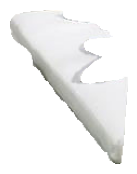

['couch', 'couch', 'couch', 'couch', 'couch', 'couch', 'couch', 'couch', 'couch', 'couch']
couch
1.0


In [11]:
# checking if everything is okay
i=3
image_data.masks[i].plot()
print(image_data.masks[i].labels)
print(image_data.masks[i].most_freq_label)
print(image_data.masks[i].most_freq_prob)

In [12]:
import importlib
import src.models.KG as kg_module
importlib.reload(kg_module)
from src.models.KG import KnowledgeGraph

In [13]:
# call the KG builder
llm = create_llm_instance("openai", "gpt-4o-mini", temperature = 0.1)
KG = KnowledgeGraph(llm, image_data)
print(">>> plot_relationship_matrix" in dir(KnowledgeGraph))

False


In [15]:
triples = KG.generate_triples( image_data.masks )
triples

Created bbox dictionary with 27 masks
Debug mode enabled-----------------------------------------
Prompt for Spatial Analysis:
Consider the following dictionary that contains a set of objects in the scene. 
        Analyze the spatial relationships between these objects based on their positions. 
        Analyze the properties of the objects (ex: shape, color, complexity, functionality, etc.).
        Analyze the functionality of the objects.
        These are the bounding boxes: {'toy': {'label': 'toy', 'label_prob': 0.983, 'bbox': {'x_min': 3, 'x_max': 109, 'y_min': 463, 'y_max': 527}}, 'table': {'label': 'table', 'label_prob': 0.908, 'bbox': {'x_min': 208, 'x_max': 486, 'y_min': 421, 'y_max': 564}}, 'couch': {'label': 'couch', 'label_prob': 1.0, 'bbox': {'x_min': 476, 'x_max': 726, 'y_min': 405, 'y_max': 581}}, 'slipper': {'label': 'slipper', 'label_prob': 0.917, 'bbox': {'x_min': 536, 'x_max': 584, 'y_min': 426, 'y_max': 468}}, 'lamp': {'label': 'lamp', 'label_prob': 0.98, 'bbox': 

'1. (Washing_machine, is_next_to, Dryer)\n2. (Storage_cabinets, are_above, Washing_machine)\n3. (Desk, is_centered_in, Room)\n4. (Chair, is_in_front_of, Desk)\n5. (Coffee_table, is_in_front_of, Sofa)\n6. (Sofa, is_on_the_right_of, Desk)\n7. (Green_rug, is_under, Coffee_table)\n8. (Lamp, is_on, Desk)\n9. (Plants, are_on, Desk)\n10. (Art_piece, is_hanging_on, Wall)\n11. (Washing_machine, has_color, White)\n12. (Dryer, has_color, White)\n13. (Storage_cabinets, have_color, White)\n14. (Desk, has_shape, Long_flat)\n15. (Chair, has_color, Black)\n16. (Sofa, has_color, White)\n17. (Coffee_table, has_shape, Round)\n18. (Rug, has_color, Green)\n19. (Lamp, has_color, Black)\n20. (Plants, have_color, Green)\n21. (Washing_machine, is_used_for, Laundry)\n22. (Dryer, is_used_for, Drying_clothes)\n23. (Storage_cabinets, are_used_for, Storage)\n24. (Desk, is_used_for, Workspace)\n25. (Chair, is_used_for, Seating)\n26. (Sofa, is_used_for, Relaxation)\n27. (Coffee_table, is_used_for, Holding_items)\n28.

In [16]:
kg_triples = KG.parse_triples( triples )

In [17]:
KG.load_triples( os.path.join(RESULTS_DIR, "KnowledgeGraph", "triples_final", "IMG_1_unexp_triples.txt") );

Successfully loaded 50 triples from ./outputs/KnowledgeGraph/triples_final/IMG_1_unexp_triples.txt


Relationship matrix saved to outputs/KnowledgeGraph/knowledge_matrices/IMG_1_unexp_knowledge_matrix.png


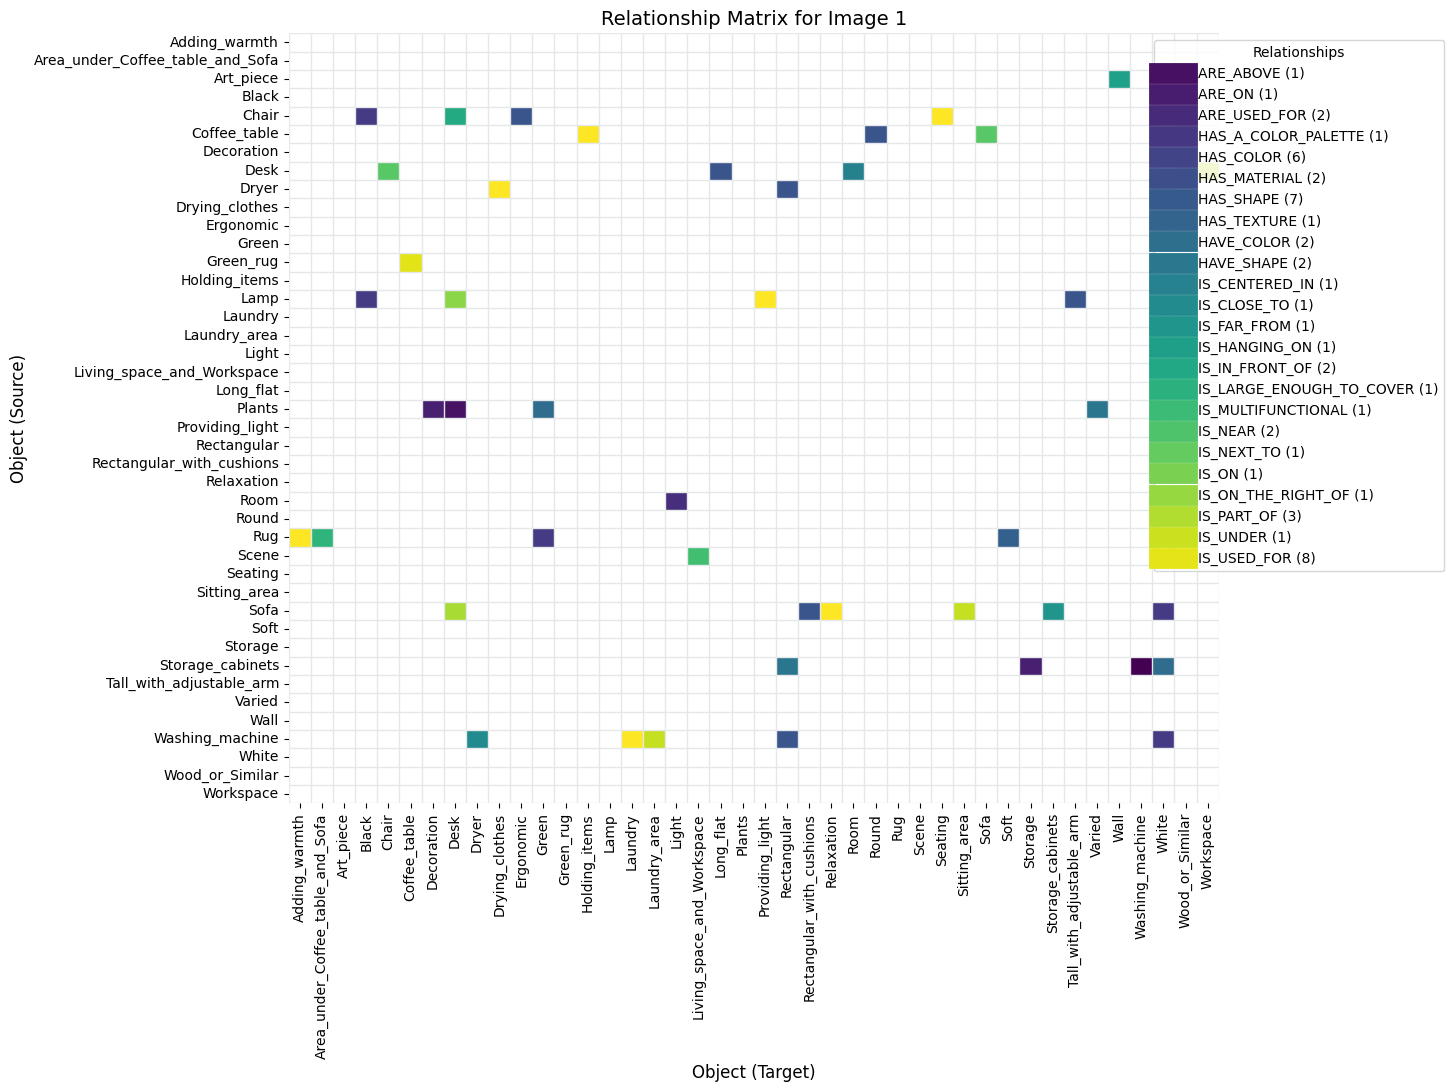

In [18]:
KG.plot_relationship_matrix()

In [19]:
KG.build_graph()

In [20]:
kg_matrix = KG.get_adjacency_matrix( save=True)
kg_matrix

Adjacency matrix saved to outputs/KnowledgeGraph/knowledge_matrices/IMG_1_unexp_adjacency_matrix.csv


,Washing_machine,Dryer,Storage_cabinets,Desk,Room,Chair,Coffee_table,Sofa,Green_rug,Lamp,...,Ergonomic,Rectangular_with_cushions,Soft,Tall_with_adjustable_arm,Varied,Light,Scene,Living_space_and_Workspace,Laundry_area,Sitting_area
Washing_machine,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
Dryer,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Storage_cabinets,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Desk,0,0,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Room,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
Chair,0,0,0,1,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
Coffee_table,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
Sofa,0,0,1,1,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
Green_rug,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Lamp,0,0,0,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


Professional knowledge graph saved to outputs/KnowledgeGraph/1_knowledge_graph_professional.png
PDF version saved to outputs/KnowledgeGraph/1_knowledge_graph_professional.pdf


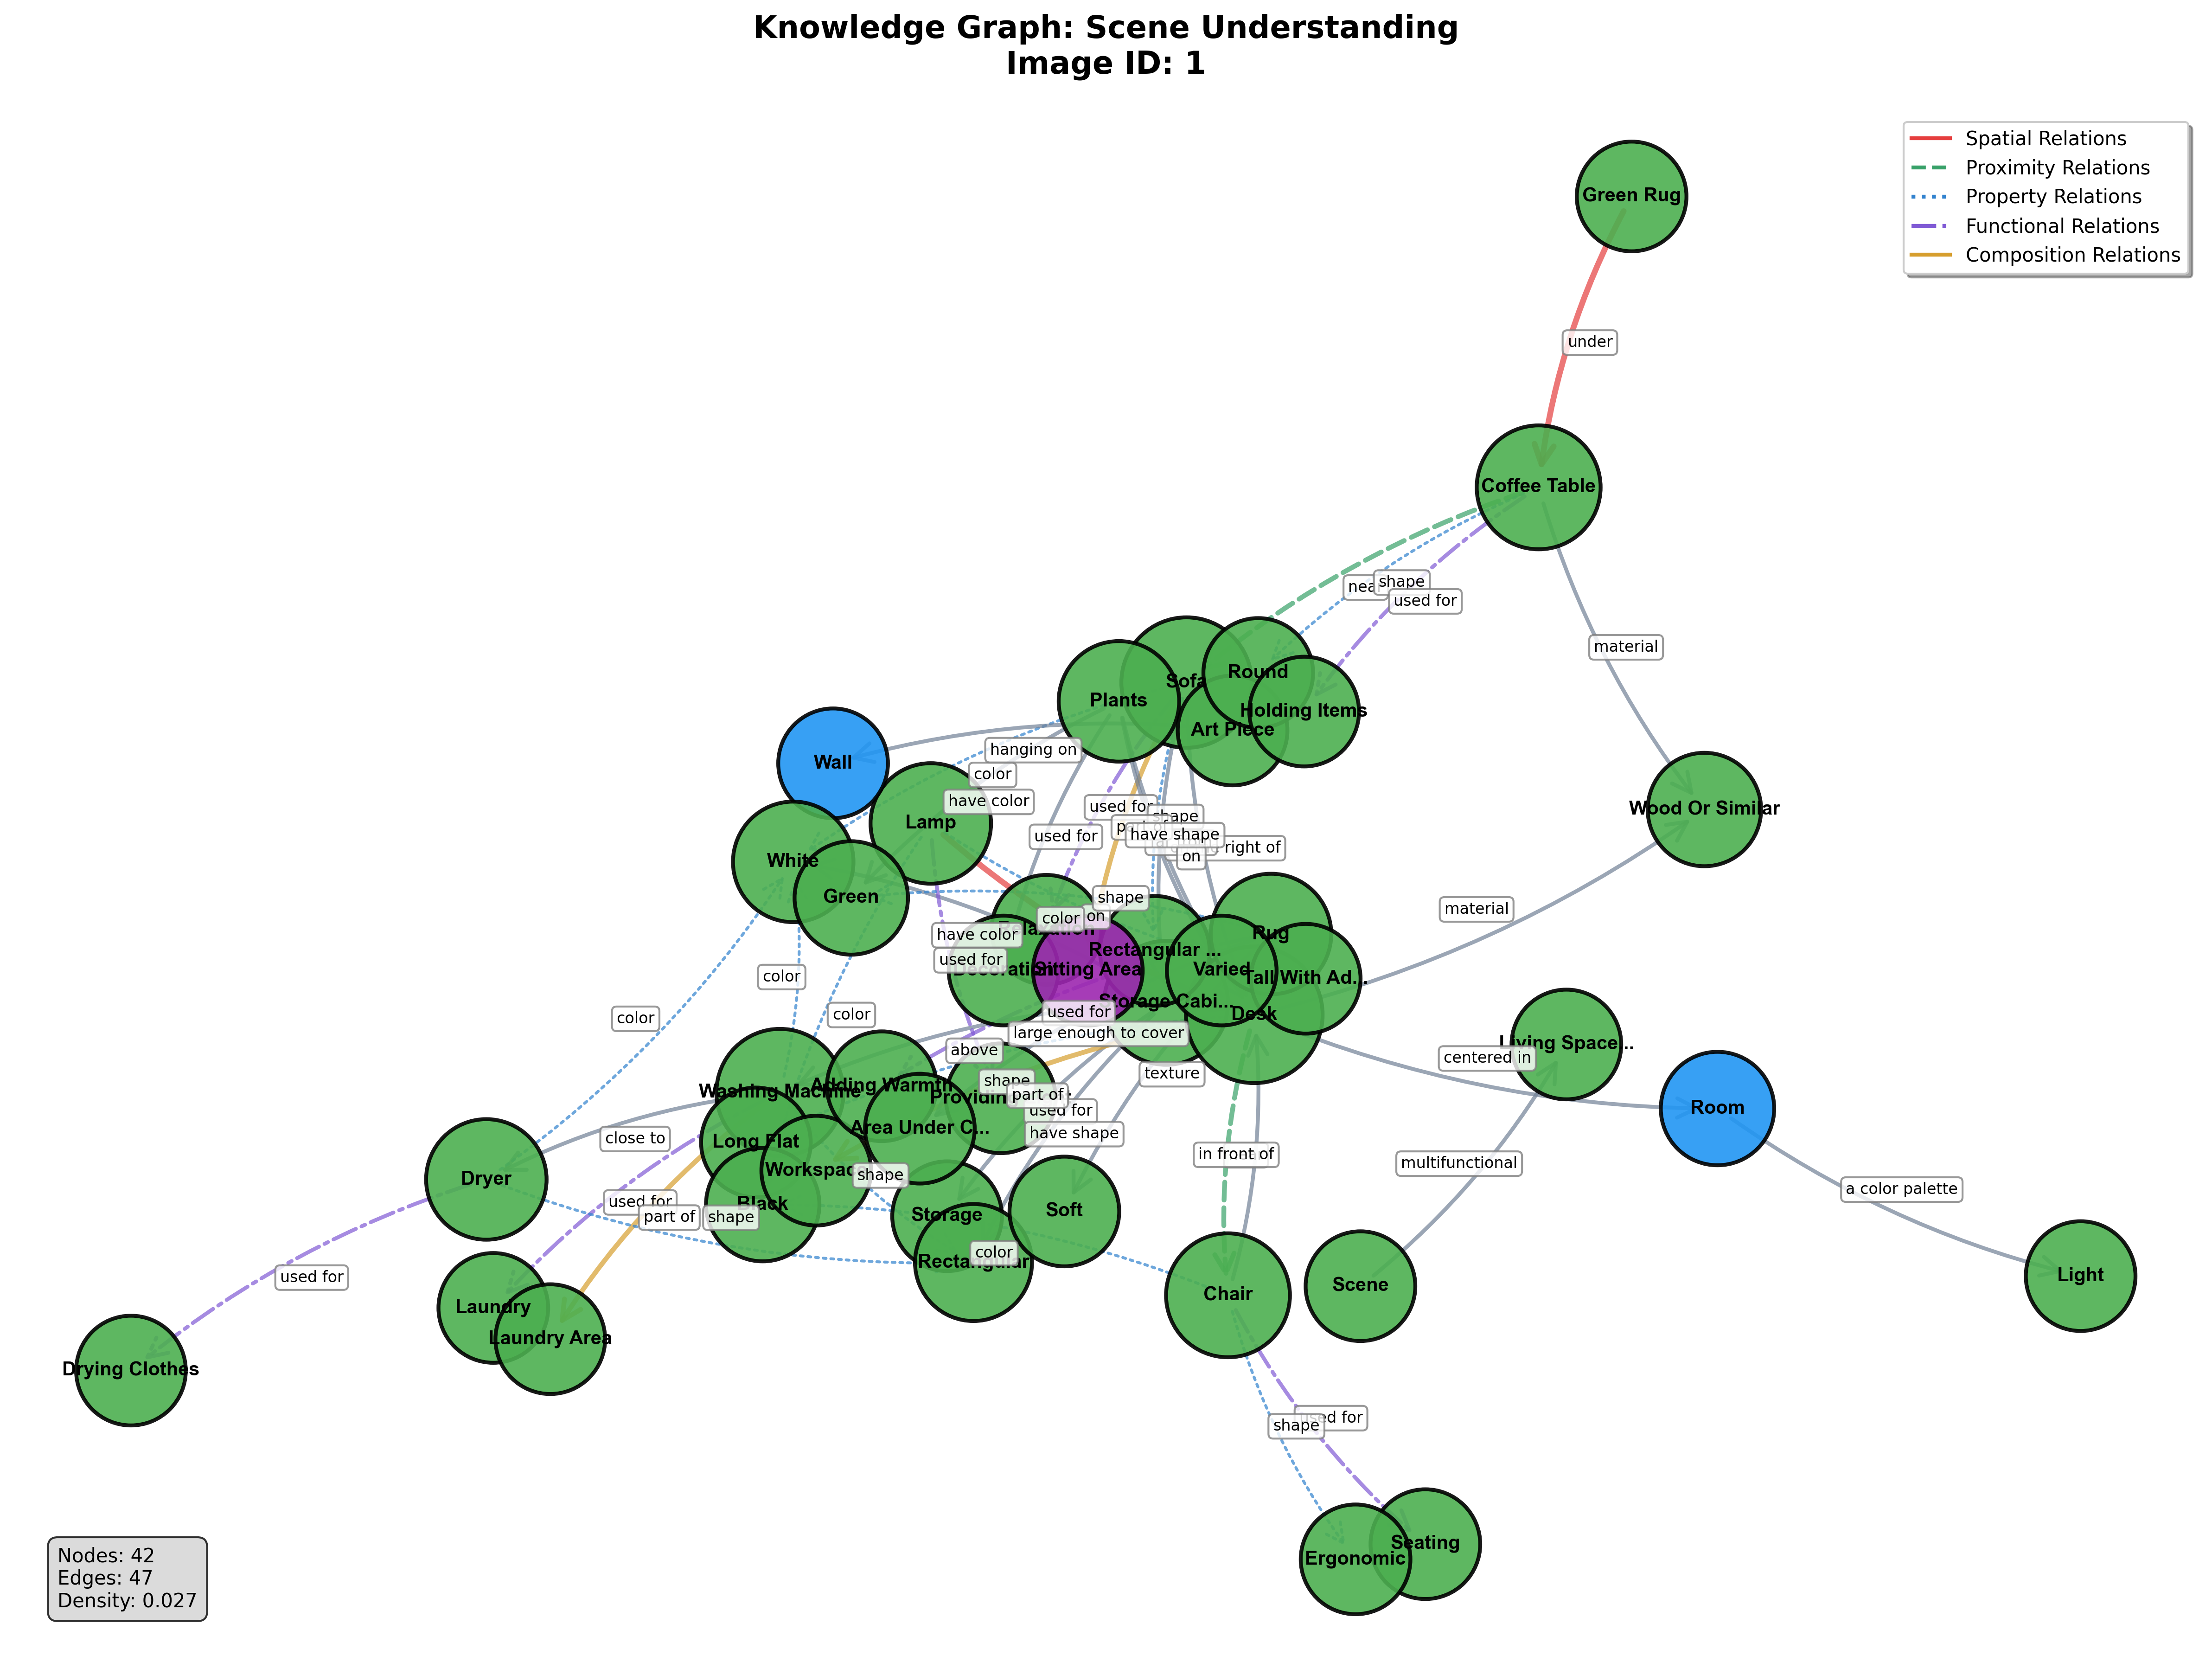

In [21]:
KG.plot_knowledge_graph(layout_algorithm="kamada_kawai", scale=5.0, k_param = 10.0)

In [22]:
llm = create_llm_instance("openai", "gpt-4o-mini", temperature = 0.1)
KG = KnowledgeGraph(llm, image_data)

In [23]:
KG.create_mask_dict(image_data.masks)

Created bbox dictionary with 27 masks


In [24]:
# 1) Call the aggregation
KG.create_mask_dict(image_data.masks)

# 2) Point your verification snippet at the same list:
masks = image_data.masks

import numpy as np
from collections import defaultdict

# Re‐group by label
groups = defaultdict(list)
for mask in masks:
    lbl = mask.most_freq_label.lower().strip()
    groups[lbl].append(mask)

# Recompute & compare
for label, group in groups.items():
    xmins = [m.x_min for m in group]
    xmaxs = [m.x_max for m in group]
    ymins = [m.y_min for m in group]
    ymaxs = [m.y_max for m in group]
    probs  = [m.most_freq_prob for m in group]
    
    computed = {
      'x_min': int(np.mean(xmins)),
      'x_max': int(np.mean(xmaxs)),
      'y_min': int(np.mean(ymins)),
      'y_max': int(np.mean(ymaxs)),
      'label_prob': round(float(np.mean(probs)), 2)
    }
    
    print(f"{label!r} ⇒ computed avg:", computed)
    print(f"           aggregated in KG.bbox_info:", 
          KG.bbox_info[label]['bbox'], 
          "prob=", KG.bbox_info[label]['label_prob'])
    print()



Created bbox dictionary with 27 masks
'toy' ⇒ computed avg: {'x_min': 4, 'x_max': 50, 'y_min': 473, 'y_max': 497, 'label_prob': 0.96}
           aggregated in KG.bbox_info: {'x_min': 3, 'x_max': 109, 'y_min': 463, 'y_max': 527} prob= 0.983

'table' ⇒ computed avg: {'x_min': 208, 'x_max': 486, 'y_min': 421, 'y_max': 564, 'label_prob': 0.91}
           aggregated in KG.bbox_info: {'x_min': 208, 'x_max': 486, 'y_min': 421, 'y_max': 564} prob= 0.908

'couch' ⇒ computed avg: {'x_min': 476, 'x_max': 726, 'y_min': 405, 'y_max': 581, 'label_prob': 1.0}
           aggregated in KG.bbox_info: {'x_min': 476, 'x_max': 726, 'y_min': 405, 'y_max': 581} prob= 1.0

'slippers' ⇒ computed avg: {'x_min': 536, 'x_max': 584, 'y_min': 426, 'y_max': 468, 'label_prob': 0.92}


KeyError: 'slippers'

In [25]:
KG.bbox_info

{'toy': {'label': 'toy',
  'label_prob': 0.983,
  'bbox': {'x_min': 3, 'x_max': 109, 'y_min': 463, 'y_max': 527}},
 'table': {'label': 'table',
  'label_prob': 0.908,
  'bbox': {'x_min': 208, 'x_max': 486, 'y_min': 421, 'y_max': 564}},
 'couch': {'label': 'couch',
  'label_prob': 1.0,
  'bbox': {'x_min': 476, 'x_max': 726, 'y_min': 405, 'y_max': 581}},
 'slipper': {'label': 'slipper',
  'label_prob': 0.917,
  'bbox': {'x_min': 536, 'x_max': 584, 'y_min': 426, 'y_max': 468}},
 'lamp': {'label': 'lamp',
  'label_prob': 0.98,
  'bbox': {'x_min': 487, 'x_max': 578, 'y_min': 181, 'y_max': 399}},
 'washing': {'label': 'washing',
  'label_prob': 1.0,
  'bbox': {'x_min': 53, 'x_max': 139, 'y_min': 326, 'y_max': 431}},
 'rug': {'label': 'rug',
  'label_prob': 1.0,
  'bbox': {'x_min': 82, 'x_max': 574, 'y_min': 477, 'y_max': 599}},
 'plant': {'label': 'plant',
  'label_prob': 1.0,
  'bbox': {'x_min': 282, 'x_max': 321, 'y_min': 398, 'y_max': 434}},
 'chair': {'label': 'chair',
  'label_prob': 0.